# 07 — Advanced Model: ViT-B/16 (Vision Transformer)
### Dataset: FaceForensics++ (C23) | Cross-Dataset: Celeb-DF v2
This notebook covers:
- ViT-B/16 as a Vision Transformer deepfake detector
- Self-attention mechanisms to capture global-consistency anomalies
- Temporal average pooling across 16 frames for video-level classification
- Two-stage training: frozen backbone → full fine-tuning
- Evaluation on FF++ test set with confusion matrix and ROC curve
- Zero-shot cross-dataset evaluation on Celeb-DF v2
- Generalization gap analysis
- Model and results saved to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import gc
import copy
import time
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path

import timm

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

Mounted at /content/drive
All libraries imported successfully.
PyTorch version : 2.10.0+cu128
CUDA available  : True


In [ ]:
# Reload project paths and constants to make this notebook fully self-contained
PROJECT_ROOT = Path("/content/drive/MyDrive/deepfake_binary_project")

PROC_ROOT  = PROJECT_ROOT / "processed"
INDEX_DIR  = PROJECT_ROOT / "index"
MODEL_DIR  = PROJECT_ROOT / "models"
PLOTS_DIR  = PROJECT_ROOT / "eda_plots"

FFPP_FACES_ROOT    = PROC_ROOT / "ffpp_face_crops_224"
CELEBDF_FACES_ROOT = PROC_ROOT / "celebdf_face_crops_224"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED        = 42
NUM_FRAMES  = 16
IMG_SIZE    = 224
BATCH_SIZE  = 8
NUM_WORKERS = 2
ACCUM_STEPS = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

print(f"Device              : {device} ({torch.cuda.get_device_name(0)})")
print(f"Frames/video        : {NUM_FRAMES}")
print(f"Image size          : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Gradient accum steps: {ACCUM_STEPS}")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Device              : cuda (Tesla T4)
Frames/video        : 16
Image size          : 224x224
Batch size          : 8
Gradient accum steps: 4
Effective batch size: 32


In [ ]:
# Load pre-built split index files generated in notebook 01
train_df   = pd.read_csv(INDEX_DIR / "ffpp_train.csv")
val_df     = pd.read_csv(INDEX_DIR / "ffpp_val.csv")
test_df    = pd.read_csv(INDEX_DIR / "ffpp_test.csv")
df_celebdf = pd.read_csv(INDEX_DIR / "celebdf_test.csv")

print("Index files loaded successfully.")
print(f"\nFF++ Train : {len(train_df)} videos  (real: {(train_df.binary_target==0).sum()} | fake: {(train_df.binary_target==1).sum()})")
print(f"FF++ Val   : {len(val_df)} videos  (real: {(val_df.binary_target==0).sum()} | fake: {(val_df.binary_target==1).sum()})")
print(f"FF++ Test  : {len(test_df)} videos  (real: {(test_df.binary_target==0).sum()} | fake: {(test_df.binary_target==1).sum()})")
print(f"\nCeleb-DF v2: {len(df_celebdf)} videos  (real: {(df_celebdf.binary_target==0).sum()} | fake: {(df_celebdf.binary_target==1).sum()})")

Index files loaded successfully.

FF++ Train : 4200 videos  (real: 700 | fake: 3500)
FF++ Val   : 900 videos  (real: 150 | fake: 750)
FF++ Test  : 900 videos  (real: 150 | fake: 750)

Celeb-DF v2: 6529 videos  (real: 890 | fake: 5639)


In [ ]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=10),
    T.RandomGrayscale(p=0.02),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class DeepfakeDataset(Dataset):
    """
    Loads pre-extracted MTCNN face crops and applies the specified transform.
    Returns a tensor of shape (T, C, H, W) and a binary label.
    """
    def __init__(self, df, faces_root, transform=None, num_frames=NUM_FRAMES):
        self.df         = df.reset_index(drop=True)
        self.faces_root = Path(faces_root)
        self.transform  = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        vid_stem  = Path(row["path"]).stem
        label     = int(row["binary_target"])
        frame_dir = self.faces_root / row["binary_label"] / vid_stem

        frames = []
        for i in range(self.num_frames):
            img = cv2.imread(str(frame_dir / f"frame_{i:02d}.jpg"))
            if img is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                img = self.transform(img)
            else:
                img = T.Compose([T.ToPILImage(), T.ToTensor()])(img)
            frames.append(img)

        return torch.stack(frames), torch.tensor(label, dtype=torch.long)

# WeightedRandomSampler to handle 1:5 class imbalance
targets = train_df["binary_target"].values
counts  = np.bincount(targets)
weights = 1.0 / counts[targets]
sampler = WeightedRandomSampler(
    weights     = torch.tensor(weights, dtype=torch.float),
    num_samples = len(weights),
    replacement = True
)

train_dataset   = DeepfakeDataset(train_df,   FFPP_FACES_ROOT,    transform=train_transform)
val_dataset     = DeepfakeDataset(val_df,     FFPP_FACES_ROOT,    transform=val_transform)
test_dataset    = DeepfakeDataset(test_df,    FFPP_FACES_ROOT,    transform=val_transform)
celebdf_dataset = DeepfakeDataset(df_celebdf, CELEBDF_FACES_ROOT, transform=val_transform)

train_loader   = DataLoader(train_dataset,   batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True)
val_loader     = DataLoader(val_dataset,     batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
test_loader    = DataLoader(test_dataset,    batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
celebdf_loader = DataLoader(celebdf_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train dataset    : {len(train_dataset)} videos  | {len(train_loader)} batches")
print(f"Val dataset      : {len(val_dataset)} videos  | {len(val_loader)} batches")
print(f"Test dataset     : {len(test_dataset)} videos  | {len(test_loader)} batches")
print(f"Celeb-DF dataset : {len(celebdf_dataset)} videos | {len(celebdf_loader)} batches")

Train dataset    : 4200 videos  | 525 batches
Val dataset      : 900 videos  | 113 batches
Test dataset     : 900 videos  | 113 batches
Celeb-DF dataset : 6529 videos | 817 batches


In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, criterion, optimizer, device, accum_steps=ACCUM_STEPS):
    model.train()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    optimizer.zero_grad()

    for step, (frames, labels) in enumerate(loader):
        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(frames)
        loss    = criterion(outputs, labels) / accum_steps
        loss.backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item() * accum_steps * labels.size(0)
        probs = torch.softmax(outputs.detach(), dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.detach().argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
    }


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(frames)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
        "y_true"   : all_labels,
        "y_pred"   : all_preds,
        "y_prob"   : all_probs,
    }


def save_results(results, path):
    """Serialize evaluation results to JSON, converting numpy types."""
    def convert(obj):
        if isinstance(obj, (np.integer)): return int(obj)
        if isinstance(obj, (np.floating)): return float(obj)
        if isinstance(obj, list): return [convert(i) for i in obj]
        return obj
    with open(path, "w") as f:
        json.dump({k: convert(v) for k, v in results.items()}, f, indent=2)


def print_epoch(epoch, total, tr, val, lr, t):
    print(f"Epoch [{epoch}/{total}]")
    print(f"  Train  loss={tr['loss']:.4f}  acc={tr['acc']:.4f}  f1={tr['f1']:.4f}  auc={tr['auc']:.4f}")
    print(f"  Val    loss={val['loss']:.4f}  acc={val['acc']:.4f}  f1={val['f1']:.4f}  auc={val['auc']:.4f}")
    print(f"  LR={lr:.6f}  time={t/60:.2f} min")
    print("-" * 65)


print("Shared training utilities defined.")

Shared training utilities defined.


## Part 1 — ViT-B/16 Model Definition
Vision Transformer (ViT-B/16) divides each frame into 16×16 patches and processes
them through multi-head self-attention layers. This allows the model to capture
global-consistency anomalies — long-range relationships between facial landmarks,
pose alignment, and structural inconsistencies — that local convolutional receptive
fields in ResNet-18 and EfficientNet-B4 cannot detect.
Each frame is processed independently through the ViT backbone and temporal
average pooling is applied across all 16 frames for video-level classification.
Training follows a two-stage strategy: frozen backbone → full fine-tuning.

In [ ]:
class ViTB16Detector(nn.Module):
    """
    ViT-B/16 binary deepfake detector.
    Processes each frame independently through patch-based self-attention
    and aggregates via temporal average pooling for video-level classification.
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        backbone = timm.create_model("vit_base_patch16_224",
                                      pretrained=True,
                                      num_classes=0)
        self.feature_extractor = backbone
        self.dropout           = nn.Dropout(dropout)
        self.classifier        = nn.Linear(backbone.num_features, 2)

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x        = x.view(B * T, C, H, W)
        features = self.feature_extractor(x)           # (B*T, num_features)
        features = features.view(B, T, -1).mean(dim=1) # temporal average pooling
        features = self.dropout(features)
        return self.classifier(features)               # (B, 2)

torch.cuda.empty_cache()
gc.collect()

vit = ViTB16Detector(dropout=0.3).to(device)

with torch.no_grad():
    dummy = torch.randn(2, NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = vit(dummy)

print(f"ViT-B/16 initialized.")
print(f"Input shape    : {dummy.shape}")
print(f"Output shape   : {out.shape}")
print(f"GPU memory     : {torch.cuda.memory_allocated()/1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16 initialized.
Input shape    : torch.Size([2, 16, 3, 224, 224])
Output shape   : torch.Size([2, 2])
GPU memory     : 0.37 GB


In [ ]:
vit_path    = MODEL_DIR / "vit_b16_best.pth"
vit_s1_path = MODEL_DIR / "vit_b16_stage1.pth"

if vit_path.exists():
    vit.load_state_dict(torch.load(vit_path, map_location=device))
    best_f1  = 0.0
    best_wts = copy.deepcopy(vit.state_dict())
    print("ViT-B/16 final weights loaded from Drive — skipping training.")
elif vit_s1_path.exists():
    vit.load_state_dict(torch.load(vit_s1_path, map_location=device))
    best_f1  = 0.0
    best_wts = copy.deepcopy(vit.state_dict())
    print("ViT-B/16 Stage 1 weights loaded from Drive — skipping Stage 1.")
else:
    # ── Stage 1: Warm up classification head with frozen backbone ──
    for param in vit.feature_extractor.parameters():
        param.requires_grad = False

    optimizer_s1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, vit.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler_s1 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_s1, T_max=10)

    best_f1  = 0.0
    best_wts = copy.deepcopy(vit.state_dict())

    print("=" * 65)
    print("ViT-B/16 — Stage 1: Frozen backbone (10 epochs)")
    print(f"Batch: {BATCH_SIZE} | Accum: {ACCUM_STEPS} | Effective: {BATCH_SIZE * ACCUM_STEPS}")
    print("=" * 65)

    for epoch in range(1, 11):
        t0      = time.time()
        train_m = train_one_epoch(vit, train_loader, criterion,
                                  optimizer_s1, device)
        val_m   = evaluate(vit, val_loader, criterion, device)
        scheduler_s1.step()

        if val_m["f1"] > best_f1:
            best_f1  = val_m["f1"]
            best_wts = copy.deepcopy(vit.state_dict())

        print_epoch(epoch, 10, train_m, val_m,
                    optimizer_s1.param_groups[0]["lr"], time.time() - t0)
        torch.cuda.empty_cache()
        gc.collect()

    vit.load_state_dict(best_wts)
    torch.save(vit.state_dict(), vit_s1_path)
    print(f"\nStage 1 complete. Best val F1 : {best_f1:.4f}")
    print(f"Stage 1 weights saved to : {vit_s1_path}")

ViT-B/16 — Stage 1: Frozen backbone (10 epochs)
Batch: 8 | Accum: 4 | Effective: 32
Epoch [1/10]
  Train  loss=0.6826  acc=0.6081  f1=0.6055  auc=0.6524
  Val    loss=0.6681  acc=0.6644  f1=0.7588  auc=0.7801
  LR=0.000976  time=49.44 min
-----------------------------------------------------------------
Epoch [2/10]
  Train  loss=0.5685  acc=0.7026  f1=0.6906  auc=0.7735
  Val    loss=0.7196  acc=0.6078  f1=0.6965  auc=0.8391
  LR=0.000905  time=16.23 min
-----------------------------------------------------------------
Epoch [3/10]
  Train  loss=0.5528  acc=0.7110  f1=0.7112  auc=0.7886
  Val    loss=0.6026  acc=0.6856  f1=0.7741  auc=0.8515
  LR=0.000794  time=15.90 min
-----------------------------------------------------------------
Epoch [4/10]
  Train  loss=0.5183  acc=0.7333  f1=0.7356  auc=0.8180
  Val    loss=0.4582  acc=0.8089  f1=0.8764  auc=0.8734
  LR=0.000655  time=15.86 min
-----------------------------------------------------------------
Epoch [5/10]
  Train  loss=0.505

In [ ]:
# Force complete GPU memory release
del vit
torch.cuda.synchronize()
torch.cuda.empty_cache()
gc.collect()

print(f"GPU memory after reset : {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Reinitialize ViT and load Stage 1 weights
vit = ViTB16Detector(dropout=0.3).to(device)
vit.load_state_dict(torch.load(vit_s1_path, map_location=device))
best_f1  = 0.0
best_wts = copy.deepcopy(vit.state_dict())

print(f"GPU memory after reload : {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("ViT-B/16 Stage 1 weights reloaded — ready for Stage 2.")

GPU memory after reset : 0.98 GB
GPU memory after reload : 1.32 GB
ViT-B/16 Stage 1 weights reloaded — ready for Stage 2.


In [ ]:
vit_s2_path = MODEL_DIR / "vit_b16_stage2_best.pth"

if vit_s2_path.exists():
    vit.load_state_dict(torch.load(vit_s2_path, map_location=device))
    best_f1  = 0.0
    best_wts = copy.deepcopy(vit.state_dict())
    print("ViT-B/16 Stage 2 weights loaded from Drive — skipping training.")
else:
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    gc.collect()

    print(f"GPU memory before Stage 2 : {torch.cuda.memory_allocated()/1e9:.2f} GB")

    for param in vit.parameters():
        param.requires_grad = True

    BATCH_SIZE_S2  = 2
    ACCUM_STEPS_S2 = 16

    train_loader_s2 = DataLoader(train_dataset, batch_size=BATCH_SIZE_S2,
                                  sampler=sampler, num_workers=NUM_WORKERS,
                                  pin_memory=False)
    val_loader_s2   = DataLoader(val_dataset, batch_size=BATCH_SIZE_S2,
                                  shuffle=False, num_workers=NUM_WORKERS,
                                  pin_memory=False)

    optimizer_s2 = torch.optim.AdamW(vit.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=10)

    print("=" * 65)
    print("ViT-B/16 — Stage 2: Full fine-tuning (10 epochs)")
    print(f"Batch: {BATCH_SIZE_S2} | Accum: {ACCUM_STEPS_S2} | Effective: {BATCH_SIZE_S2 * ACCUM_STEPS_S2}")
    print("=" * 65)

    for epoch in range(1, 11):
        t0      = time.time()
        train_m = train_one_epoch(vit, train_loader_s2, criterion,
                                  optimizer_s2, device, accum_steps=ACCUM_STEPS_S2)
        val_m   = evaluate(vit, val_loader_s2, criterion, device)
        scheduler_s2.step()

        if val_m["f1"] > best_f1:
            best_f1  = val_m["f1"]
            best_wts = copy.deepcopy(vit.state_dict())

        print_epoch(epoch, 10, train_m, val_m,
                    optimizer_s2.param_groups[0]["lr"], time.time() - t0)
        torch.cuda.empty_cache()
        gc.collect()

    vit.load_state_dict(best_wts)
    torch.save(vit.state_dict(), vit_s2_path)
    torch.save(vit.state_dict(), vit_path)
    print(f"\nStage 2 complete. Best val F1 : {best_f1:.4f}")
    print(f"Model saved to : {vit_s2_path}")

GPU memory before Stage 2 : 1.32 GB
ViT-B/16 — Stage 2: Full fine-tuning (10 epochs)
Batch: 2 | Accum: 16 | Effective: 32
Epoch [1/10]
  Train  loss=0.5102  acc=0.8093  f1=0.8134  auc=0.8937
  Val    loss=0.1036  acc=0.9633  f1=0.9779  auc=0.9894
  LR=0.000098  time=43.15 min
-----------------------------------------------------------------
Epoch [2/10]
  Train  loss=0.1170  acc=0.9531  f1=0.9530  auc=0.9916
  Val    loss=0.1221  acc=0.9533  f1=0.9713  auc=0.9954
  LR=0.000090  time=43.14 min
-----------------------------------------------------------------
Epoch [3/10]
  Train  loss=0.0482  acc=0.9824  f1=0.9826  auc=0.9984
  Val    loss=0.1192  acc=0.9567  f1=0.9743  auc=0.9912
  LR=0.000079  time=43.23 min
-----------------------------------------------------------------
Epoch [4/10]
  Train  loss=0.0378  acc=0.9850  f1=0.9847  auc=0.9991
  Val    loss=0.3483  acc=0.9267  f1=0.9540  auc=0.9905
  LR=0.000065  time=43.14 min
------------------------------------------------------------

In [ ]:
print("Evaluating ViT-B/16 on FF++ test set...")
vit_ffpp_m = evaluate(vit, test_loader, criterion, device)

print(f"\nFF++ Test Results:")
print(f"  Loss      : {vit_ffpp_m['loss']:.4f}")
print(f"  Accuracy  : {vit_ffpp_m['acc']:.4f}")
print(f"  Precision : {vit_ffpp_m['precision']:.4f}")
print(f"  Recall    : {vit_ffpp_m['recall']:.4f}")
print(f"  F1-Score  : {vit_ffpp_m['f1']:.4f}")
print(f"  AUC       : {vit_ffpp_m['auc']:.4f}")

save_results(vit_ffpp_m, MODEL_DIR / "vit_b16_ffpp_results.json")
print("\nFF++ results saved to Drive.")

Evaluating ViT-B/16 on FF++ test set...

FF++ Test Results:
  Loss      : 0.0625
  Accuracy  : 0.9778
  Precision : 1.0000
  Recall    : 0.9733
  F1-Score  : 0.9865
  AUC       : 0.9994

FF++ results saved to Drive.


Classification Report — FF++ Test Set (ViT-B/16):

              precision    recall  f1-score   support

        real       0.88      1.00      0.94       150
        fake       1.00      0.97      0.99       750

    accuracy                           0.98       900
   macro avg       0.94      0.99      0.96       900
weighted avg       0.98      0.98      0.98       900



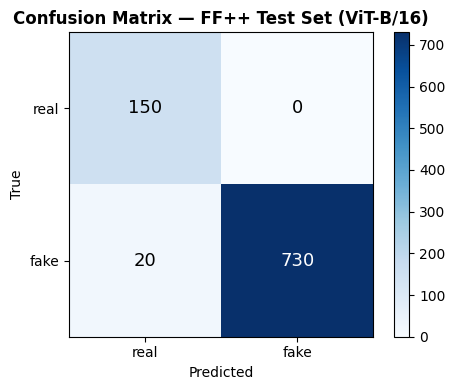

In [ ]:
print("Classification Report — FF++ Test Set (ViT-B/16):\n")
print(classification_report(vit_ffpp_m["y_true"], vit_ffpp_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(vit_ffpp_m["y_true"], vit_ffpp_m["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion Matrix — FF++ Test Set (ViT-B/16)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "23_vit_ffpp_cm.png"), dpi=150, bbox_inches="tight")
plt.show()

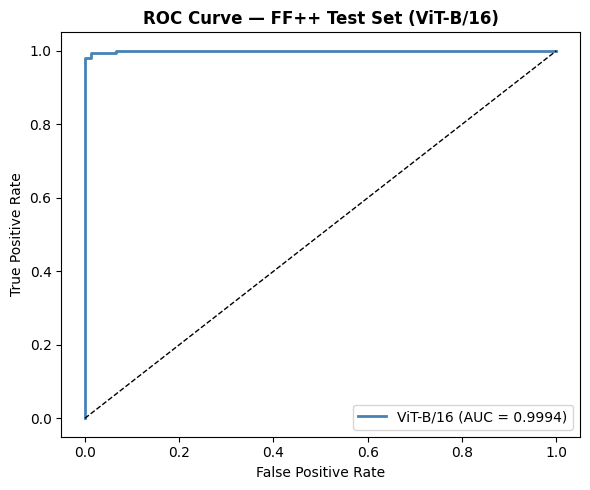

In [ ]:
fpr, tpr, _ = roc_curve(vit_ffpp_m["y_true"], vit_ffpp_m["y_prob"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ViT-B/16 (AUC = {vit_ffpp_m['auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve — FF++ Test Set (ViT-B/16)", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "23b_vit_ffpp_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
celebdf_loader_fast = DataLoader(celebdf_dataset, batch_size=32,
                                  shuffle=False, num_workers=NUM_WORKERS,
                                  pin_memory=True)

print("Evaluating ViT-B/16 on Celeb-DF v2 (zero-shot)...")
vit_celebdf_m = evaluate(vit, celebdf_loader_fast, criterion, device)

print(f"\nCeleb-DF v2 Results:")
print(f"  Loss      : {vit_celebdf_m['loss']:.4f}")
print(f"  Accuracy  : {vit_celebdf_m['acc']:.4f}")
print(f"  Precision : {vit_celebdf_m['precision']:.4f}")
print(f"  Recall    : {vit_celebdf_m['recall']:.4f}")
print(f"  F1-Score  : {vit_celebdf_m['f1']:.4f}")
print(f"  AUC       : {vit_celebdf_m['auc']:.4f}")

save_results(vit_celebdf_m, MODEL_DIR / "vit_b16_celebdf_results.json")
print("\nCeleb-DF v2 results saved to Drive.")

Evaluating ViT-B/16 on Celeb-DF v2 (zero-shot)...

Celeb-DF v2 Results:
  Loss      : 1.7727
  Accuracy  : 0.6211
  Precision : 0.9862
  Recall    : 0.5692
  F1-Score  : 0.7218
  AUC       : 0.8837

Celeb-DF v2 results saved to Drive.


Classification Report — Celeb-DF v2 (ViT-B/16):

              precision    recall  f1-score   support

        real       0.26      0.95      0.41       890
        fake       0.99      0.57      0.72      5639

    accuracy                           0.62      6529
   macro avg       0.62      0.76      0.56      6529
weighted avg       0.89      0.62      0.68      6529



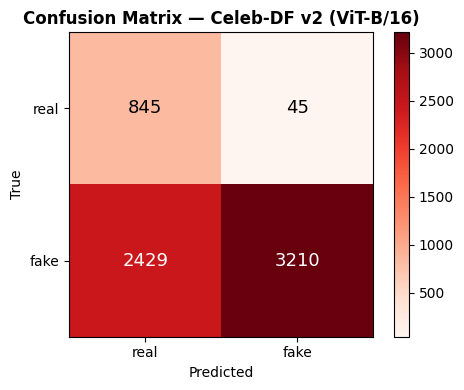

In [ ]:
print("Classification Report — Celeb-DF v2 (ViT-B/16):\n")
print(classification_report(vit_celebdf_m["y_true"], vit_celebdf_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(vit_celebdf_m["y_true"], vit_celebdf_m["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Reds")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion Matrix — Celeb-DF v2 (ViT-B/16)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "24_vit_celebdf_cm.png"), dpi=150, bbox_inches="tight")
plt.show()

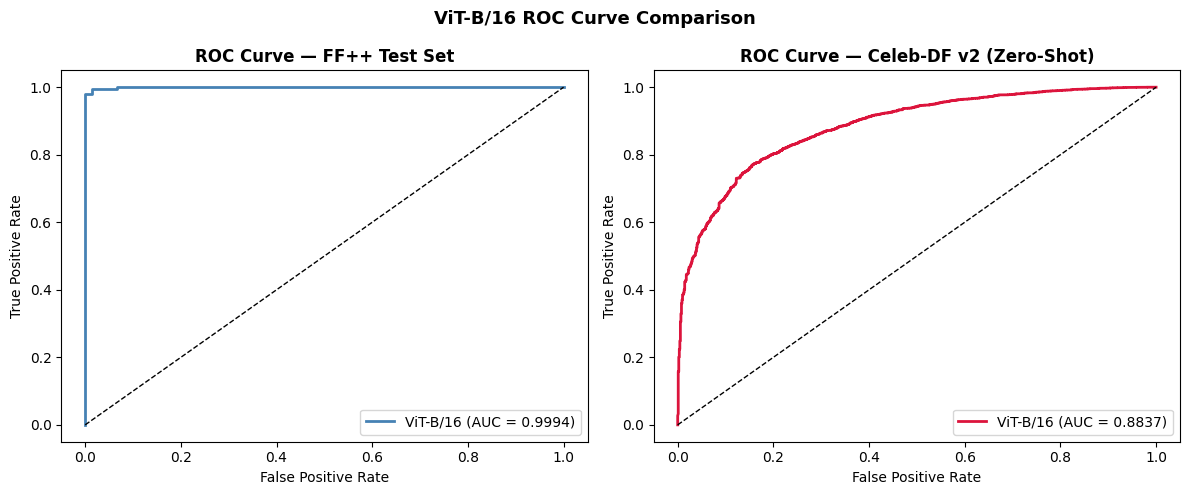

Generalization Gap (Δgen AUC) : 0.1157
  FF++ AUC     : 0.9994
  Celeb-DF AUC : 0.8837


In [ ]:
fpr_ff, tpr_ff, _ = roc_curve(vit_ffpp_m["y_true"], vit_ffpp_m["y_prob"])
fpr_cd, tpr_cd, _ = roc_curve(vit_celebdf_m["y_true"], vit_celebdf_m["y_prob"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_ff, tpr_ff, color="steelblue", lw=2,
             label=f"ViT-B/16 (AUC = {vit_ffpp_m['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve — FF++ Test Set", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(fpr_cd, tpr_cd, color="crimson", lw=2,
             label=f"ViT-B/16 (AUC = {vit_celebdf_m['auc']:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve — Celeb-DF v2 (Zero-Shot)", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.suptitle("ViT-B/16 ROC Curve Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "25_vit_roc_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

gen_gap = vit_ffpp_m["auc"] - vit_celebdf_m["auc"]
print(f"Generalization Gap (Δgen AUC) : {gen_gap:.4f}")
print(f"  FF++ AUC     : {vit_ffpp_m['auc']:.4f}")
print(f"  Celeb-DF AUC : {vit_celebdf_m['auc']:.4f}")

In [ ]:
print("=" * 55)
print("ViT-B/16 — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"\n{'Metric':<20} {'FF++ Test':>12} {'Celeb-DF v2':>12} {'Gap':>10}")
print("-" * 55)
for m, ff, cd in [
    ("Accuracy",  vit_ffpp_m["acc"],       vit_celebdf_m["acc"]),
    ("Precision", vit_ffpp_m["precision"], vit_celebdf_m["precision"]),
    ("Recall",    vit_ffpp_m["recall"],    vit_celebdf_m["recall"]),
    ("F1-Score",  vit_ffpp_m["f1"],        vit_celebdf_m["f1"]),
    ("AUC",       vit_ffpp_m["auc"],       vit_celebdf_m["auc"]),
]:
    print(f"  {m:<18} {ff:>12.4f} {cd:>12.4f} {ff-cd:>+10.4f}")

gen_gap = vit_ffpp_m["auc"] - vit_celebdf_m["auc"]
print(f"\n  Generalization Gap (Δgen AUC) : {gen_gap:.4f}")
print("=" * 55)

ViT-B/16 — FINAL RESULTS SUMMARY

Metric                  FF++ Test  Celeb-DF v2        Gap
-------------------------------------------------------
  Accuracy                 0.9778       0.6211    +0.3567
  Precision                1.0000       0.9862    +0.0138
  Recall                   0.9733       0.5692    +0.4041
  F1-Score                 0.9865       0.7218    +0.2647
  AUC                      0.9994       0.8837    +0.1157

  Generalization Gap (Δgen AUC) : 0.1157
